In [51]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import yfinance as yf
import datetime as dt
import seaborn as sb

end_date = dt.date.today()
start_date = end_date - dt.timedelta(days = 5*365)

stocks = ["AAPL","MSFT","JPM","KO","XOM"]

df = yf.download(stocks, start= start_date, end = end_date)['Close']

df.head()

[*********************100%***********************]  5 of 5 completed


Ticker,AAPL,JPM,KO,MSFT,XOM
Date,,,,,
2021-05-17,123.081924,145.124176,47.076992,235.264816,52.097485
2021-05-18,121.697769,143.079544,46.818508,233.249786,50.623116
2021-05-19,121.541817,141.986755,46.672047,233.826813,49.408432
2021-05-20,124.095642,141.739975,47.085609,237.058365,49.291145
2021-05-21,122.263123,143.352707,47.059753,235.798447,49.358170


In [52]:
df.isnull().sum()

Ticker
AAPL    0
JPM     0
KO      0
MSFT    0
XOM     0
dtype: int64

In [53]:
returns = df.pct_change().dropna()
returns.head()

Ticker,AAPL,JPM,KO,MSFT,XOM
Date,,,,,
2021-05-18,-0.011246,-0.014089,-0.005491,-0.008565,-0.028300
2021-05-19,-0.001281,-0.007638,-0.003128,0.002474,-0.023995
2021-05-20,0.021012,-0.001738,0.008861,0.013820,-0.002374
2021-05-21,-0.014767,0.011378,-0.000549,-0.005315,0.001360
2021-05-24,0.013314,0.005410,0.003296,0.022882,0.011711


In [54]:
returns_pct = returns*100
returns_pct

Ticker,AAPL,JPM,KO,MSFT,XOM
Date,,,,,
2021-05-18,-1.124580,-1.408884,-0.549066,-0.856494,-2.830020
2021-05-19,-0.128147,-0.763763,-0.312828,0.247386,-2.399464
2021-05-20,2.101191,-0.173805,0.886104,1.382028,-0.237382
2021-05-21,-1.476699,1.137810,-0.054913,-0.531480,0.135976
2021-05-24,1.331422,0.541014,0.329552,2.288199,1.171077
...,...,...,...,...,...
2026-05-08,2.045650,-1.361538,-0.012753,-1.342775,-1.371261
2026-05-11,-0.126267,-0.695136,0.306051,-0.592598,3.534610
2026-05-12,0.724339,1.626668,1.741667,-1.184998,0.634696


In [55]:
returns.describe()

Ticker,AAPL,JPM,KO,MSFT,XOM
count,1254.000000,1254.000000,1254.000000,1254.000000,1254.000000
mean,0.000855,0.000697,0.000478,0.000580,0.000999
std,0.017295,0.015351,0.010049,0.016596,0.016785
min,-0.092456,-0.074838,-0.069626,-0.099931,-0.078853
25%,-0.007581,-0.007365,-0.005264,-0.007662,-0.008779
50%,0.001059,0.000976,0.000641,0.000550,0.001308
75%,0.009627,0.009081,0.006044,0.009881,0.011249
max,0.153288,0.115445,0.047250,0.101337,0.064113


In [62]:
returns.cumsum().tail()

Ticker,AAPL,JPM,KO,MSFT,XOM
Date,,,,,
2026-05-08,1.054169,0.880589,0.573588,0.740376,1.197303
2026-05-11,1.052907,0.873638,0.576649,0.734450,1.232649
2026-05-12,1.060150,0.889905,0.594066,0.722600,1.238996
2026-05-13,1.073956,0.874718,0.596940,0.716322,1.245236
2026-05-14,1.071748,0.873586,0.599307,0.726736,1.253219


Text(0, 0.5, 'Cumulative Returns')

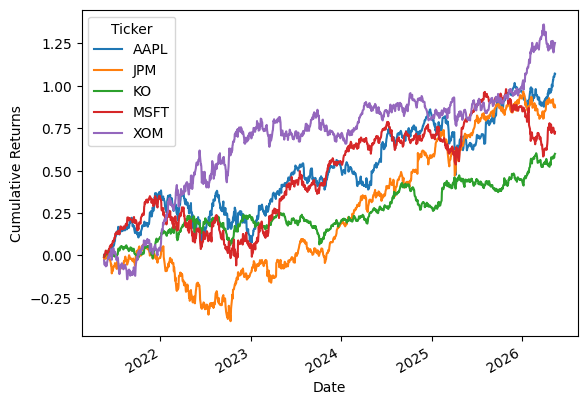

In [65]:
returns.cumsum().plot(legend=True)
plt.ylabel('Cumulative Returns')

In [58]:
corr_matrix = returns.corr()
corr_matrix

Ticker,AAPL,JPM,KO,MSFT,XOM
Ticker,,,,,
AAPL,1.000000,0.374204,0.269036,0.584384,0.187106
JPM,0.374204,1.000000,0.215074,0.317440,0.313090
KO,0.269036,0.215074,1.000000,0.159565,0.166647
MSFT,0.584384,0.317440,0.159565,1.000000,0.059201
XOM,0.187106,0.313090,0.166647,0.059201,1.000000


<Axes: xlabel='Ticker', ylabel='Ticker'>

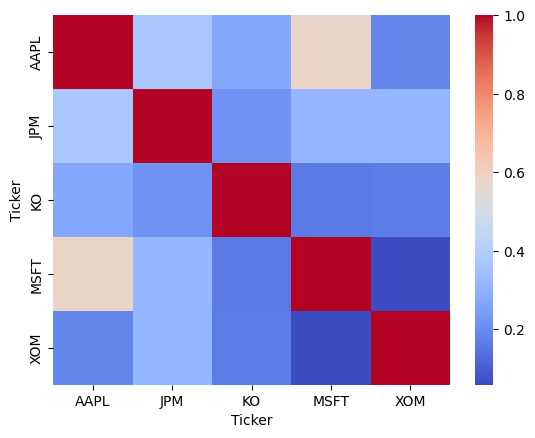

In [59]:
sb.heatmap(corr_matrix, cmap='coolwarm')    

In [60]:
cov_matrix = returns.cov()
cov_matrix

Ticker,AAPL,JPM,KO,MSFT,XOM
Ticker,,,,,
AAPL,0.000299,0.000099,0.000047,0.000168,0.000054
JPM,0.000099,0.000236,0.000033,0.000081,0.000081
KO,0.000047,0.000033,0.000101,0.000027,0.000028
MSFT,0.000168,0.000081,0.000027,0.000275,0.000016
XOM,0.000054,0.000081,0.000028,0.000016,0.000282


<Axes: xlabel='Ticker', ylabel='Ticker'>

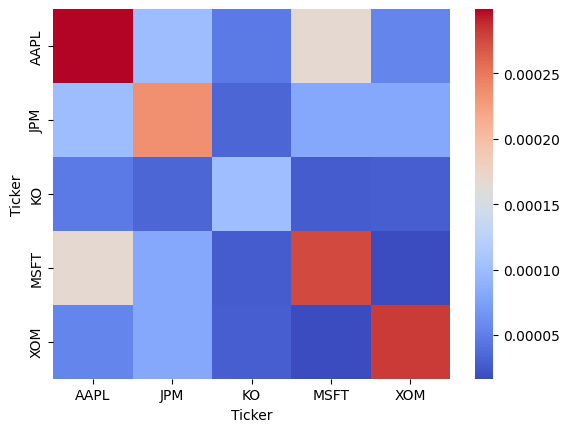

In [61]:
sb.heatmap(cov_matrix, cmap='coolwarm')